# Iris Model Evaluation & Visualization Notebook

This notebook demonstrates how to:
1. Run the `evaluate_model()` function to generate embeddings and compute similarity scores
2. Use the `plot()` function to visualize results (ROC, DET curves, histograms, and metrics)

## 1. Import Required Libraries

Import torch, custom modules, and utilities needed for evaluation.

In [1]:
import sys
import os
import torch
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import DataLoader

# Add the parent directory to path for imports
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))

# Import evaluation functions
from evaluation import evaluate_model, IRIS_TEST_FOLDER, IRIS_TRAIN_FOLDER
from Evaluation.utils import plot_scores, write_scores, load_scores


/data1/dhruv/miniconda/envs/torch312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Set Up Configuration Parameters

Configure evaluation parameters including model name, data paths, batch size, and output file.

In [2]:
# Configuration parameters
config = {
    'model_name': 'edgenext_x_small',  # Model identifier
    'iris_test_folder': IRIS_TEST_FOLDER,
    'iris_train_folder': IRIS_TRAIN_FOLDER,
    'output_filename': 'scores_iris.txt',  # Will be saved in LOGS/
    'batch_size': 32,
    'use_asymmetric_conv': True,
    'preserve_vertical': True,
    'use_cosine_similarity': True,  # True for cosine, False for Euclidean
}

# Create LOGS directory if it doesn't exist
os.makedirs('LOGS', exist_ok=True)

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  model_name: edgenext_x_small
  iris_test_folder: ../masked_dataset_augmented/test
  iris_train_folder: ../masked_dataset_augmented/train
  output_filename: scores_iris.txt
  batch_size: 32
  use_asymmetric_conv: True
  preserve_vertical: True
  use_cosine_similarity: True


## 3. Load and Prepare the Model

Load a pretrained model and move it to the appropriate device (GPU/CPU).

In [3]:
# Example: Load model using backbones.timmfr (adjust as needed for your setup)
from edgeface.backbones.timmfr import get_timmfrv2

# Uncomment and adjust the model loading code based on your actual model setup:
model = get_timmfrv2(
    model_name=config['model_name'],
   
)



## 4. Run Model Evaluation

Execute `evaluate_model()` to generate embeddings for test/train sets and compute similarity scores.
The function returns two dictionaries of embeddings and also saves scores to a file.

In [5]:
# Call evaluate_model() - this generates embeddings and saves scores
# Uncomment the following when your model is ready:

X = evaluate_model(
    model=model,  # Your loaded model
    iris_test_folder=config['iris_test_folder'],
    iris_train_folder=config['iris_train_folder'],
    output_filename=config['output_filename'],
    model_name=config['model_name'],
    use_asymmetric_conv=config['use_asymmetric_conv'],
    preserve_vertical=config['preserve_vertical'],
    batch_size=config['batch_size'],
    use_cosine_similarity=config['use_cosine_similarity']
)

print("When ready, call:")
print("X = evaluate_model(model, ...config...)")
print("\nX will be a tuple: (embedding_dict_test, embedding_dict_train)")
print("  - embedding_dict_test: dict with keys like '001_S1001R01' mapping to embeddings")
print("  - embedding_dict_train: dict with keys like '001_S1001R01' mapping to embeddings")
print("\nScores are also saved to: LOGS/scores_iris.txt")

 Model loaded and moved to cuda
Total parameters: 2,242,620

Loading datasets...
✓ Test samples: 32324
✓ Train samples: 32524

Generating embeddings...
  Processing test set...
  Processing train set...


KeyboardInterrupt: 

✓ Scores file found: LOGS/scores_iris.txt

Calling plot() function to visualize...

Read 5178875 valid pairs from 5178884 lines (9 skipped)
Genuine total: 12800
Impostor total: 5166075

Equal Error Rate (EER): 33.20%

--- TMR at Specific FMR values ---
TMR at FMR 0.1% = 98.85%
TMR at FMR 0.01% = 99.62%
TMR at FMR 0.001% = 99.95%


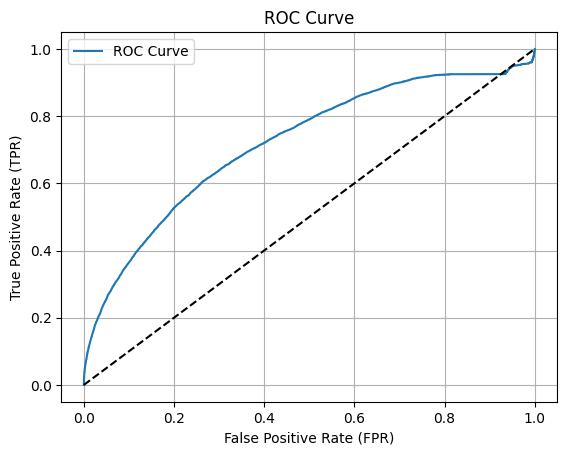

<Figure size 640x480 with 0 Axes>

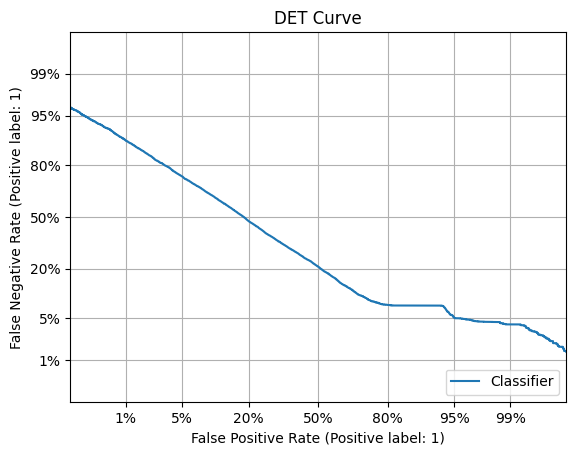

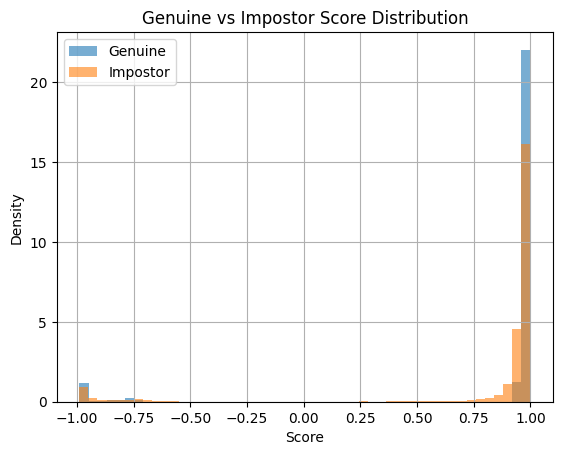

In [7]:
# Once evaluate_model() has been run and scores are saved,
# use the plot() function to visualize results

scores_file = os.path.join('LOGS', config['output_filename'])

# Check if scores file exists
if os.path.exists(scores_file):
    
    # Call plot function - displays ROC, DET, and histogram
    plot_scores(scores_file)
else:
    print(f"⚠ Scores file not found: {scores_file}")
    print("  Make sure to run evaluate_model() first (cell above)")